# Introduction to `torch.einsum`

In this lab, we'll explore how `torch.einsum` works, understand Einstein summation notation, and apply it to various tensor operations. By the end of this session, you'll be able to use `einsum` to implement complex tensor computations efficiently.


# 1. Understanding Einstein Summation Notation

Einstein summation notation is a concise way to represent various tensor operations like multiplication, transpositions and broadcasting. It allows us to express multiple operations without explicitly writing out summations.  `torch.einsum` utilizes this notation to perform tensor contractions efficiently.

It's high expressivity and readibility that comes from explicitly naming dimensons, makes this operation very practical for prototyping compex ideas fast in a concise and less bug-prone way. This makes it a popular choice for research purposes where optimizing MFU is not the highest priority.


```
torch.einsum('ik,kj->ij', A, B)
```
- `torch.einsum` gets __equation__ format string and a list of tensors.
- __Equation__ folows the format `"indices1, indices2, indices3 ... -> indices_result"`.
- Each __indicies__ string represents dimensions of a corresponding input tensor.
- Last __indicies__ string represents dimensions of the output.
- __Indices__ is a string of characters representing dimensions of a given tensor.
- The counterintuitive trick that `torch.einsum` uses: _this is unambiguous notation_ and already defines a specified linear transformaton. Let's analyse how this works for two tensors:
  - dimensions that are in the input and output act like batching (broadcasting)
  - dimensions that are only in both of the inputs are multipled out (like vectors)
  - dimensions that are only in one input are reduced with summation
- Since dimensions are named, it allows for arbitrary dimension permutations within a given operation.

Moreover, since multiplication is commutative and associative, this is also _unambiguous_ for multiple arguments and `torch.einsum` finds the computationally optimal order of multiplication.


Let's see how this works in code.

---

# 2. Basic Operations with `torch.einsum`




###Matrix Multiplication

#### Explanation:

`ik,kj->ij`: Multiply A and B over the shared index k, resulting in a matrix with indices i and j.

In [31]:
import torch

A = torch.tensor([[1, 2], [3, 4]])
B = torch.tensor([[5, 6], [7, 8]])

matrix_multiplication = torch.einsum('ik,kj->ij', A, B)
print(f"{matrix_multiplication=}")

matrix_multiplication=tensor([[19, 22],
        [43, 50]])


### Dot Product

In [32]:
a = torch.tensor([1, 2, 3])
b = torch.tensor([4, 5, 6])

dot_product = torch.einsum('i,i->', a, b)
print(f"{dot_product=}")

dot_product=tensor(32)


### Weighted sum
$y_i = \sum_j W_{ij} x_j$


In [33]:
W = torch.tensor([[1, 2, 3], [4, 5, 6]])
x = torch.tensor([2, 1, 0])

weighted_sum = torch.einsum('ij,j->i', W, x)
print(f"{weighted_sum=}")

weighted_sum=tensor([ 4, 13])


###Outer Product
  $C_{ij} = a_i b_j$

#### Explanation:

`i,j->ij`: No summation since indices i and j are free; the result is a matrix.

In [34]:
a = torch.tensor([1, 2, 3])
b = torch.tensor([4, 5])

outer_product = torch.einsum('i,j->ij', a, b)
print(f"{outer_product=}")

outer_product=tensor([[ 4,  5],
        [ 8, 10],
        [12, 15]])


### Implementing Other PyTorch Functions with einsum


In [35]:
A = torch.tensor([[1, 2], [3, 4]])

A_transpose = torch.einsum('ij->ji', A)
print(f"{A_transpose=}")

A_transpose=tensor([[1, 3],
        [2, 4]])


In [36]:
sum_over_rows = torch.einsum('ij->j', A)
print(f"{sum_over_rows=}")

sum_over_rows=tensor([4, 6])


### Batched Matrix Multiplication

Einsum is especially practical for batching various operations

`bij,bjk->bik`: b is the batch index, i, j, k are matrix indices.


In [37]:
A = torch.randn(10, 3, 4)
B = torch.randn(10, 4, 5)

C = torch.einsum('bij,bjk->bik', A, B)
print(f"{C.shape=}")

C.shape=torch.Size([10, 3, 5])


### Batched Outer Product

Now, try to implement a batched version of the outer product.

In [38]:
A = torch.randn(10, 3)
B = torch.randn(10, 4)

# TODO
outer_products = torch.einsum('bi,bj->bij', A, B)
# TODO

print(f"{outer_products.shape=}")

outer_products.shape=torch.Size([10, 3, 4])


## Optimizing Computations with einsum

Einsum optimizes the order of operations (based on tensors shape) to minimize computation time.

`ik,kj,jl->il`: two contracted matrix multiplications.



In [39]:
A = torch.randn(2, 3)
B = torch.randn(3, 4)
C = torch.randn(4, 5)

D = torch.einsum('ik,kj,jl->il', A, B, C)
print(f"{D.shape=}")

D.shape=torch.Size([2, 5])



## `einops` library

`einops` is a simple library providing some syntax sugar to `torch.einsum`. The main difference is that dimensions can be named with strings and are separated with spaces, which makes the code much more readable. Also, the string is the last argument.














In [40]:
from einops import einsum
import torch

X = torch.randn(3, 4)
B = torch.randn(4, 4)

Y = einsum(X, B, "batch dmodel, dmodel dmodel -> batch dmodel")
print(f"{Y.shape=}")
# Student's notes:
torch.manual_seed(0)
X = torch.randint(5,(3, 4))
B = torch.randint(5, (4, 4))
Y2 = einsum(X,B, "batch d, d d -> batch d")
print(X)
print(B)
# print(Y)
print(Y2)
# We can see it multiply b,d element from X by d,d element from B

Y.shape=torch.Size([3, 4])
tensor([[4, 4, 3, 0],
        [3, 4, 2, 3],
        [2, 3, 1, 1]])
tensor([[1, 4, 3, 1],
        [1, 3, 4, 3],
        [1, 4, 1, 4],
        [4, 1, 4, 4]])
tensor([[ 4, 12,  3,  0],
        [ 3, 12,  2, 12],
        [ 2,  9,  1,  4]])


#### `einops.rearrange`

`einops.rearrange` is used for reshaping and permuting dimensions without data duplication. It provides a clear way to change the order of axes and reshape tensors.

In [41]:
from einops import rearrange, einsum
import torch

image = torch.randn(1, 3, 64*64)

image = rearrange(image, "batch channels (height width) -> batch height width channels", height=64)
print(f"{image.shape=}")

image.shape=torch.Size([1, 64, 64, 3])


#### `einops.repeat`

`einops.repeat` lets you easily add new dimensions or repeat along specified dimensions.

In [42]:
from einops import repeat

X = torch.tensor([1, 2, 3])

X_out = repeat(X, "v -> b v", b=5)
print(f"{X_out.shape=}")

X_out = repeat(X, "v -> (b v)", b=5)
print(f"{X_out.shape=}")

X_out.shape=torch.Size([5, 3])
X_out.shape=torch.Size([15])



# (TASK) Implementing Grouped Query Attention with `einops`

## Grouped Query Attention

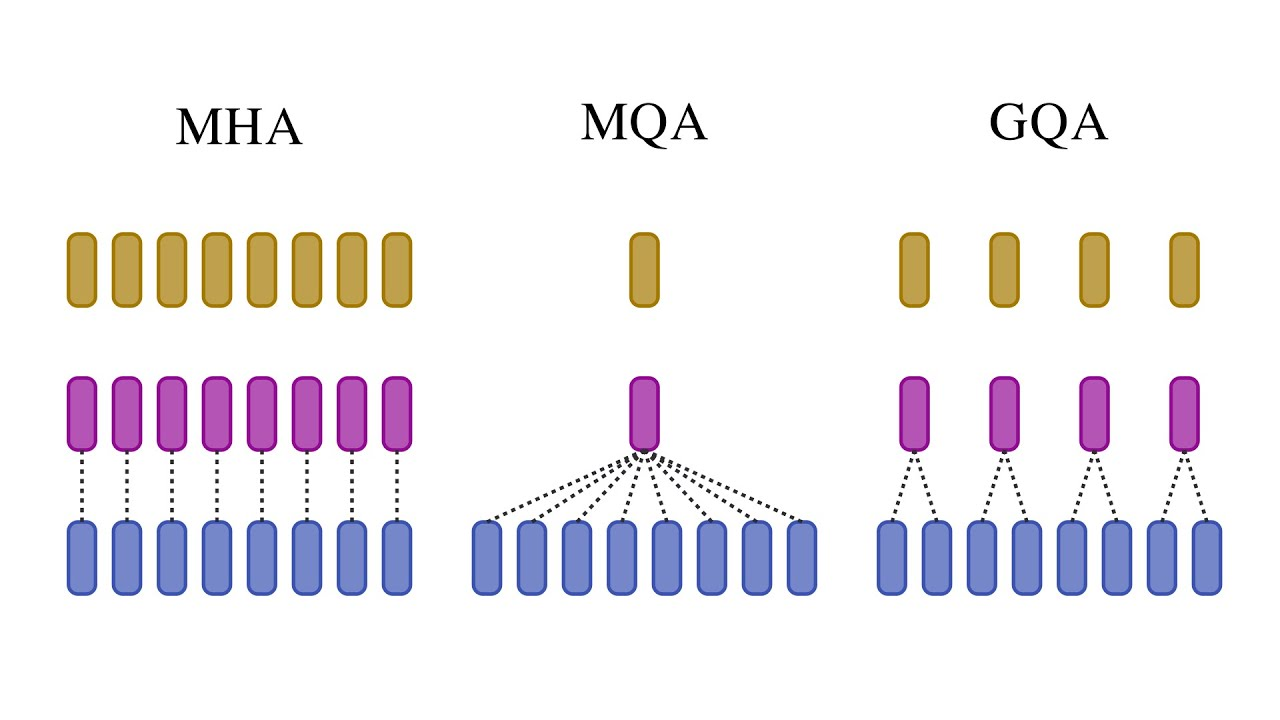

__Grouped Query Attention__ (GQA) is a modified version of the self-attention mechanism used to improve inference efficiency in LLMs, especially for tasks with large input sequences. In GQA, the queries (input points that need information) are divided into groups that share the same keys and values, instead of each query having its own unique keys and values. This reduces the amount of data that the model needs to store at inference (__KV-cache__), while still allowing each query to attend to relevant information. This is why this trick is often used for production-grade LLMs.  

Example:
- Suppose you have 8 attention heads.
- You divide them into 2 groups
  - Group 1: Heads 1-4 share K and V, but have different Q.
  - Group 2: Heads 5-8 share K and V, but have different Q


## TASK


implement __Grouped Query Attention__ using _only_ `einops` operations imported in the code. If you prefer the syntax, you can use `torch.einsum` instead of `einops.einsum`. Do not use any other torch operations like reshape, view, bmm etc.

Note that any consecutive  two einsum operations that are meant to produce one tensor can be merged into one. Using this, implement the function using einops operations at most __7 times__. However, you can try to reduce it as much as possible.

_Hint: at first just implement it as you like, then just merge operations._




In [43]:
from einops import rearrange, repeat, einsum
from torch import softmax


def grouped_query_attention(x, query_weight, key_weight, value_weight, projection_weight,
                            embed_size, nheads, ngroups):
    head_dim = embed_size // nheads
    gsize = nheads // ngroups

    ### TODO
    assert len(x.shape) == 3
    b = x.shape[0]
    seq = x.shape[1]
    assert embed_size == x.shape[2]
    # x: (b, seq, embed_dim)
    assert query_weight.shape == (embed_size, nheads, head_dim)
    assert key_weight.shape == (embed_size, ngroups, head_dim)
    assert value_weight.shape == (embed_size, ngroups, head_dim)
    print("b, seq, embed_size =", x.shape)
    print(f"head_dim: {head_dim}, nheads: {nheads}, gsize: {gsize}, ngroups: {ngroups}")
    print("Wq:", query_weight.shape)
    print("Wk:", key_weight.shape)
    print("Wv:", value_weight.shape)
    print("Wp:", projection_weight.shape)

    Q = einsum(x, query_weight, "b seq embed_size, embed_size nheads head_dim -> b seq nheads head_dim")
    K = einsum(x, key_weight, "b seq embed_dim, embed_dim ngroups head_dim -> b seq ngroups head_dim")
    V = einsum(x, value_weight, "b seq embed_dim, embed_dim ngroups head_dim -> b seq ngroups head_dim")

    K_rep = repeat(K, "b seq ngroups head_dim -> b seq (ngroups r) head_dim", r=gsize)
    V_rep = repeat(V, "b seq ngroups head_dim -> b seq (ngroups r) head_dim", r=gsize)

    scores = einsum(Q, K_rep, "b seq_q nheads head_dim, b seq_k nheads head_dim -> b nheads seq_q seq_k")
    scores = scores * (1.0 / (head_dim ** 0.5))

    attn = softmax(scores, dim=-1)
    # b nheads seq_q seq_k, b seq_k nheads head_dim -> b nheads seq_q head_dim
    # b nheads seq_q head_dim, nheads head_dim embed_dim -> b seq_q embed_dim

    out = einsum(attn, V_rep, projection_weight, "b nheads seq_q seq_k, b seq_k nheads head_dim, nheads head_dim embed_dim -> b seq_q embed_dim")

    return out

    ### TODO


Code below is for testing your solution and should not be changed.

This code assumes that the dot-product scaling factor is: `1/(head_dim ** 0.5)`

In [44]:
import torch
torch.manual_seed(42)

batch_size = 1
seq_len = 3
embed_size = 8
nheads = 4
ngroups = 2
head_dim = embed_size // nheads
gsize = nheads // ngroups

x = torch.randn(batch_size, seq_len, embed_size)
query_weight = torch.randn(embed_size, nheads, head_dim)
key_weight = torch.randn(embed_size, ngroups, head_dim)
value_weight = torch.randn(embed_size, ngroups, head_dim)
projection_weight = torch.randn(nheads, head_dim, embed_size)

output = grouped_query_attention(x, query_weight, key_weight, value_weight, projection_weight,
                                 embed_size, nheads, ngroups)

print(f"{output.shape=}")
print(f"{output=}")

desired_shape = (batch_size, seq_len, embed_size)
desired_output = torch.tensor([[[-3.1446, -6.7115,  4.4947,  8.8615, -3.9177, -5.5313, -6.5142, -3.0563],
                                [-1.4355, -5.8312,  7.3457, 10.4629, -4.8407, -5.1714, -7.5018, -2.9113],
                                [ 7.0097,  1.4967,  6.2741,  1.2851, -1.7647, 12.2188,  5.8315, 3.5446]]])

assert output.shape == desired_shape
assert torch.allclose(output, desired_output, atol=1e-2)

b, seq, embed_size = torch.Size([1, 3, 8])
head_dim: 2, nheads: 4, gsize: 2, ngroups: 2
Wq: torch.Size([8, 4, 2])
Wk: torch.Size([8, 2, 2])
Wv: torch.Size([8, 2, 2])
Wp: torch.Size([4, 2, 8])
output.shape=torch.Size([1, 3, 8])
output=tensor([[[-3.1446, -6.7115,  4.4947,  8.8615, -3.9177, -5.5313, -6.5142,
          -3.0563],
         [-1.4355, -5.8312,  7.3457, 10.4629, -4.8407, -5.1714, -7.5018,
          -2.9113],
         [ 7.0097,  1.4967,  6.2741,  1.2851, -1.7647, 12.2188,  5.8315,
           3.5446]]])



# Additional Materials

Einsum is highly expressive, but there are some operations that it cannot implement efficiently. Functions below are presented for completeness. Together, operations presented in this notebook allow to implement practically any architecture (not accounting for element-wise functions and distributed algorithms).

## Fold & Unfold

#### Implementing Convolution

`torch.unfold` and `torch.fold` are torch primitives that allow for dividing multidimensional tensors into patches, and creating tensors from patches. The simplest explanation can be illustrated by implementing convolution using matrix multiplication.

In [45]:
import torch
import torch.nn.functional as F

image = torch.tensor([[[1, 2, 3, 4],
                       [1, 2, 2, 2],
                       [1, 2, 3, 3],
                       [1, 2, 3, 4]]], dtype=torch.float32)


# unfold the image to get 2x2 patches with a stride of 1
patches = F.unfold(image, kernel_size=2, stride=1)
print(f"{patches.shape=}\n{patches=}\n")

conv_kernel = torch.tensor([[1, 0],[0, -1]], dtype=torch.float32).view(1, -1)
convolved = conv_kernel @ patches
print(f"{convolved.shape=}\n{convolved}\n")

output = F.fold(convolved.view(1, 1, -1), output_size=(3, 3), kernel_size=1, stride=1)
print(f"{output.shape=}\n{output}\n")

patches.shape=torch.Size([4, 9])
patches=tensor([[1., 2., 3., 1., 2., 2., 1., 2., 3.],
        [2., 3., 4., 2., 2., 2., 2., 3., 3.],
        [1., 2., 2., 1., 2., 3., 1., 2., 3.],
        [2., 2., 2., 2., 3., 3., 2., 3., 4.]])

convolved.shape=torch.Size([1, 9])
tensor([[-1.,  0.,  1., -1., -1., -1., -1., -1., -1.]])

output.shape=torch.Size([1, 1, 3, 3])
tensor([[[[-1.,  0.,  1.],
          [-1., -1., -1.],
          [-1., -1., -1.]]]])



#### Patched Tokens for ViT

Image Transformer called ViT is applying a transformer on a tokenized image. This tokenization divides an image into non-intersecting square patches. Your task here is to implement this tokenization.

In [49]:
image = torch.tensor([[[1, 2, 3, 4],
                        [1, 2, 2, 2],
                        [1, 2, 3, 3],
                        [1, 2, 3, 4]]], dtype=torch.float32)
# TODO

patch_size = 2

patches = F.unfold(
    image,
    kernel_size=patch_size,
    stride=patch_size
)

print("patches.shape =", patches.shape)
print(patches)

patches.shape = torch.Size([4, 4])
tensor([[1., 3., 1., 3.],
        [2., 4., 2., 3.],
        [1., 2., 1., 3.],
        [2., 2., 2., 4.]])


## Indexing



#### `gather`: Retrieving Values from Specific Indices

`gather` lets you extract values from a tensor along a specific dimension based on an index tensor. This operation preserves gradients in expected way, and is therefore used for various conditional computation tasks.

In [47]:
import torch

table = torch.tensor([[91, 80, 70, 55],
                       [55, 23, 85, 75],
                       [71, 83, 98, 68]])  # shape: (3, 4)

indices = torch.tensor([[0, 0], [2, 1], [2, 3]])  # shape: (3, 2)

extracted = torch.gather(table, 1, indices)
print(extracted)

tensor([[91, 91],
        [85, 23],
        [98, 68]])



#### `scatter`: Placing Values into Specific Indices
On the contrary, `scatter` allows you to place values into specific positions in a tensor, given their indices.

In [48]:
table = torch.tensor([[91, 80, 70, 55],
                       [55, 23, 85, 75],
                       [71, 83, 98, 68]])  # shape: (3, 4)

indices = torch.tensor([[0, 0], [2, 1], [2, 3]])  # shape: (3, 2)

values_to_set = torch.tensor([[-1, 1], [-1, 1], [-1, 1]]) # shape: (3, 2)

table.scatter_(1, indices, values_to_set)
print(table)

tensor([[ 1, 80, 70, 55],
        [55,  1, -1, 75],
        [71, 83, -1,  1]])
